In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

In [3]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
X=iris.data
y=iris.target

In [4]:
iris_data = pd.DataFrame(iris['data'], columns=iris['feature_names'])
name_map = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2:'Iris-virginica'}
iris_data['class'] = [name_map[k] for k in iris['target']]
iris_data.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=5)


model = LogisticRegression()
model.fit(X_train, y_train) #Обучение трейновой выборке
y_pred = model.predict(X_test) #Предсказание для тестовой выборки
print(accuracy_score(y_test, y_pred))
print(f1_score(y_test, y_pred, average='macro'))

0.9130434782608695
0.9074074074074074


<Axes: >

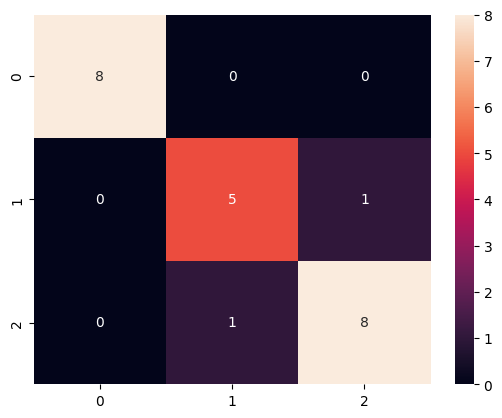

In [6]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

1.0
1.0


<Axes: >

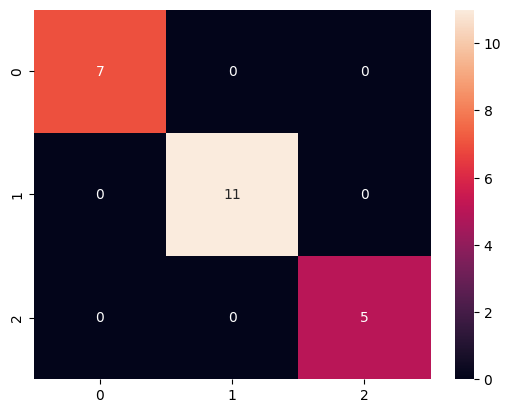

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=0)
model = LogisticRegression()
model.fit(X_train, y_train) #Обучение трейновой выборке
y_pred = model.predict(X_test) #Предсказание для тестовой выборки
print(accuracy_score(y_test, y_pred))
print(f1_score(y_test, y_pred, average='macro'))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

0.8695652173913043
0.8745098039215686


<Axes: >

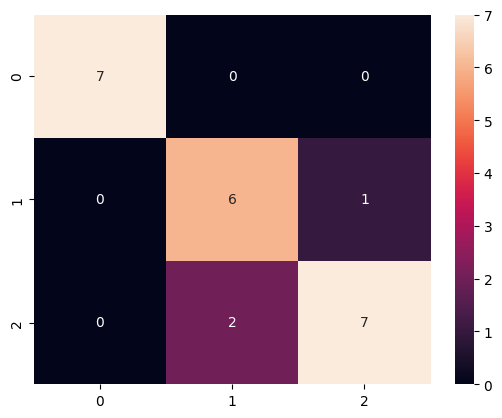

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=8)
model = LogisticRegression()
model.fit(X_train, y_train) #Обучение трейновой выборке
y_pred = model.predict(X_test) #Предсказание для тестовой выборки
print(accuracy_score(y_test, y_pred))
print(f1_score(y_test, y_pred, average='macro'))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

In [9]:
from sklearn.model_selection import KFold,StratifiedKFold,LeaveOneOut, cross_val_score
kf = KFold(n_splits = 3,shuffle=True, random_state=15)
kf


KFold(n_splits=3, random_state=15, shuffle=True)

In [10]:
for i, (train_index, test_index) in enumerate(kf.split(y)):
    print("Fold {}: Длинна train: {}, Длинна test: {}".format(i+1, len(train_index), len(test_index)))
    print('Train: index={}\n Test:  index={}'.format(train_index, test_index))

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

Fold 1: Длинна train: 100, Длинна test: 50
Train: index=[  1   2   3   4   7  10  14  15  16  17  18  19  22  23  24  26  28  29
  32  33  34  35  37  38  39  40  41  42  43  44  45  46  49  50  51  52
  53  54  56  60  62  63  64  65  66  68  69  70  73  75  76  77  79  80
  81  82  83  85  87  88  91  92  93  94  96  99 101 102 104 105 106 107
 108 110 111 113 114 117 118 119 120 121 123 125 128 131 132 133 134 135
 136 137 139 140 141 142 144 145 146 147]
 Test:  index=[  0   5   6   8   9  11  12  13  20  21  25  27  30  31  36  47  48  55
  57  58  59  61  67  71  72  74  78  84  86  89  90  95  97  98 100 103
 109 112 115 116 122 124 126 127 129 130 138 143 148 149]
Fold 2: Длинна train: 100, Длинна test: 50
Train: index=[  0   1   4   5   6   7   8   9  10  11  12  13  15  17  19  20  21  22
  23  24  25  26  27  28  30  31  34  36  37  39  40  41  42  44  47  48
  50  53  55  56  57  58  59  60  61  62  63  65  66  67  70  71  72  74
  75  78  79  84  85  86  89  90  95  96  97

In [11]:
metrics_accuracy = []
metrics_f1 = []
model = LogisticRegression()
for i, (train_index, test_index) in enumerate(kf.split(y)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics_accuracy.append(accuracy_score(y_test, y_pred))
    metrics_f1.append(f1_score(y_test, y_pred, average='macro'))

In [12]:
print('Значения метрики accuracy: {} \nЗначения метрики f1: {}'.format(metrics_accuracy, metrics_f1))

Значения метрики accuracy: [1.0, 0.94, 0.94] 
Значения метрики f1: [1.0, 0.9444015444015443, 0.9352142110762801]


In [13]:
import numpy as np
print("Среднее по кросс-валидации: ", np.array(metrics_f1).mean())

Среднее по кросс-валидации:  0.9598719184926082


In [14]:
cv_results = cross_val_score(model,                  # модель
                             X,                      # матрица признаков
                             y,                      # вектор цели
                             cv = kf,                # тип разбиения (можно указать просто число фолдов cv = 3)
                             scoring = 'accuracy',   # метрика
                             n_jobs=-1)              # используются все ядра CPU

print("Кросс-валидация: ", cv_results)
print("Среднее по кросс-валидации: ", cv_results.mean())
print("Дисперсия по кросс-валидации: ", cv_results.std())

Кросс-валидация:  [1.   0.94 0.94]
Среднее по кросс-валидации:  0.96
Дисперсия по кросс-валидации:  0.028284271247461926


In [15]:
skf = StratifiedKFold(n_splits=3,shuffle=True, random_state=15)  # keeps class integrity in folds, e.g. 20% A and 80% B in each fold as well as in the entire dataset
skf.get_n_splits(X, y)


3

In [16]:
for i, (train_index, test_index) in enumerate(skf.split(X,y)):
    print(f"Fold {i+1}:")
    print('Train: index={}\n Test:  index={}'.format(train_index, test_index))

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

Fold 1:
Train: index=[  0   1   2   3   4   5   7   8   9  12  14  15  16  17  18  19  21  23
  24  25  26  28  29  31  32  36  37  38  39  40  41  44  45  51  52  53
  54  55  60  61  62  63  65  66  68  70  72  75  77  80  81  82  83  84
  85  86  87  89  90  91  93  94  95  96  97  98 101 102 103 104 105 107
 110 111 112 113 114 116 118 121 122 123 124 126 127 128 129 132 133 134
 139 140 141 142 143 144 145 146 147 149]
 Test:  index=[  6  10  11  13  20  22  27  30  33  34  35  42  43  46  47  48  49  50
  56  57  58  59  64  67  69  71  73  74  76  78  79  88  92  99 100 106
 108 109 115 117 119 120 125 130 131 135 136 137 138 148]
Fold 2:
Train: index=[  0   1   2   4   5   6   9  10  11  13  14  15  16  19  20  21  22  23
  26  27  28  29  30  31  33  34  35  42  43  46  47  48  49  50  51  54
  55  56  57  58  59  61  63  64  66  67  69  70  71  73  74  75  76  78
  79  83  84  87  88  89  90  91  92  94  96  97  99 100 101 103 105 106
 107 108 109 110 114 115 116 117 118 119 

In [17]:
cv_results = cross_val_score(model,                  # модель
                             X,                      # матрица признаков
                             y,                      # вектор цели
                             cv = skf,           # тип разбиения
                             scoring = 'f1_macro',   # метрика
                             n_jobs=-1)              # используются все ядра CPU

print("Кросс-валидация: ", cv_results)
print("Среднее по кросс-валидации: ", cv_results.mean())

Кросс-валидация:  [0.95925926 0.95955882 0.96064815]
Среднее по кросс-валидации:  0.9598220769789397


/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
loo = LeaveOneOut()  # every combination, one sample is used as test set and the rest as training set
for i, (train_index, test_index) in enumerate(loo.split(X)):
    print(f"Fold {i+1}:")
    print('Train: index={}\n Test:  index={}'.format(train_index, test_index))

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

Fold 1:
Train: index=[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149]
 Test:  index=[0]
Fold 2:
Train: index=[  0   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  

In [19]:
cv_results = cross_val_score(model,                  # модель
                             X,                      # матрица признаков
                             y,                      # вектор цели
                             cv = loo,           # тип разбиения
                             scoring = 'f1_macro',   # метрика
                             n_jobs=-1)              # используются все ядра CPU
# just cleaner than folds
print("Кросс-валидация: ", cv_results)
print("Среднее по кросс-валидации: ", cv_results.mean())

/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to sca

Кросс-валидация:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1.
 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]
Среднее по кросс-валидации:  0.9666666666666667


# EXTRA TASKS
# 1

In [20]:
from sklearn.model_selection import LeavePOut
lpo = LeavePOut(p=2)

print(f"{len(X)} samples, total {lpo.get_n_splits(X)}\n")
print("First 5 folds:")
for i, (train_index, test_index) in enumerate(lpo.split(X)):
    if i >= 5:
        break
    print(f"Fold {i+1}: Train={len(train_index)} samples, Test={len(test_index)} samples")
    print(f"  Test indices: {test_index}")

150 samples, total 11175

First 5 folds:
Fold 1: Train=148 samples, Test=2 samples
  Test indices: [0 1]
Fold 2: Train=148 samples, Test=2 samples
  Test indices: [0 2]
Fold 3: Train=148 samples, Test=2 samples
  Test indices: [0 3]
Fold 4: Train=148 samples, Test=2 samples
  Test indices: [0 4]
Fold 5: Train=148 samples, Test=2 samples
  Test indices: [0 5]


In [21]:
import time
import sys, warnings, os
if not sys.warnoptions:
    warnings.simplefilter("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore"


lpo = LeavePOut(p=2)
start_time = time.time()

cv_results = cross_val_score(model,                  # модель
                             X,                      # матрица признаков
                             y,                      # вектор цели
                             cv = lpo,               # Leave-P-Out с p=2
                             scoring = 'f1_macro',   # метрика
                             n_jobs=-1)              # все ядра CPU

elapsed_time = time.time() - start_time

print(f"\nКросс-валидация результаты (первые 20 из {len(cv_results)}):")
print(cv_results[:20])
print(f"\nСреднее по кросс-валидации: {cv_results.mean():.4f}")
print(f"Стандартное отклонение: {cv_results.std():.4f}")
print(f"Время выполнения: {elapsed_time:.2f} сек")


Кросс-валидация результаты (первые 20 из 11175):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Среднее по кросс-валидации: 0.9541
Стандартное отклонение: 0.1698
Время выполнения: 32.94 сек


# 2, 3

In [22]:
from sklearn.model_selection import cross_validate
kf = KFold(n_splits=3, shuffle=True, random_state=15)

scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

cv_results = cross_validate(model, X, y, 
                            cv=kf,
                            scoring=scoring,
                            return_train_score=True,
                            n_jobs=-1)


for key, values in cv_results.items():
    if 'time' in key:
        print(f"{key:25s}: {values.mean():.4f} sec (avg)")
    else:
        print(f"{key:25s}: {values}")

print('summary')
for key, values in cv_results.items():
    if 'time' not in key and 'estimator' not in key:
        print(f"{key:25s}: mean={values.mean():.4f}, std={values.std():.4f}")

fit_time                 : 0.0158 sec (avg)
score_time               : 0.0053 sec (avg)
test_accuracy            : [1.   0.94 0.94]
train_accuracy           : [0.98 0.99 0.97]
test_f1_macro            : [1.         0.94440154 0.93521421]
train_f1_macro           : [0.98005952 0.98956039 0.97099012]
test_precision_macro     : [1.         0.94444444 0.93472222]
train_precision_macro    : [0.98148148 0.99019608 0.97086835]
test_recall_macro        : [1.         0.94530444 0.93697479]
train_recall_macro       : [0.97979798 0.98924731 0.97138047]
summary
test_accuracy            : mean=0.9600, std=0.0283
train_accuracy           : mean=0.9800, std=0.0082
test_f1_macro            : mean=0.9599, std=0.0286
train_f1_macro           : mean=0.9802, std=0.0076
test_precision_macro     : mean=0.9597, std=0.0288
train_precision_macro    : mean=0.9808, std=0.0079
test_recall_macro        : mean=0.9608, std=0.0280
train_recall_macro       : mean=0.9801, std=0.0073


# 4

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
models = [LogisticRegression, RandomForestClassifier, SVC]

X, y = iris.data, iris.target
kf = KFold(n_splits=3, shuffle=True, random_state=15)
scoring = {'accuracy': 'accuracy'}
for model_cls in models:
    print(f"\nEvaluating model: {model_cls.__name__}")
    model = model_cls()
    cv_results = cross_validate(model, X, y, 
                                cv=kf,
                                scoring=scoring,
                                return_train_score=True,
                                n_jobs=-1)
    print(f"Test Accuracy: {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")


Evaluating model: LogisticRegression
Test Accuracy: 0.9600 ± 0.0283

Evaluating model: RandomForestClassifier
Test Accuracy: 0.9333 ± 0.0094

Evaluating model: SVC
Test Accuracy: 0.9533 ± 0.0094


# 5

In [35]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
import numpy as np

diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

kf = KFold(n_splits=3, shuffle=True, random_state=15)

scoring = {
    'r2': 'r2',
    'neg_mean_squared_error': 'neg_mean_squared_error',
    'neg_mean_absolute_error': 'neg_mean_absolute_error'
}

model = LinearRegression()
cv_results = cross_validate(model, X, y, 
                            cv=kf,
                            scoring=scoring,
                            return_train_score=True,
                            n_jobs=-1)

print(f"R2 Score: {cv_results['test_r2'].mean():.4f} ± {cv_results['test_r2'].std():.4f}")
print(f"MAE: {-cv_results['test_neg_mean_absolute_error'].mean():.4f}")
print(f"MSE: {-cv_results['test_neg_mean_squared_error'].mean():.4f}")

R2 Score: 0.4815 ± 0.0043
MAE: 44.8956
MSE: 3071.9839


# 6

In [36]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_validate
import numpy as np

diabetes = load_iris()
X, y = diabetes.data, diabetes.target

pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

kf = KFold(n_splits=3, shuffle=True, random_state=15)

scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

cv_results = cross_validate(pipeline, X, y, 
                            cv=kf,
                            scoring=scoring,
                            return_train_score=True,
                            n_jobs=-1)

print(f"\nTest Accuracy:   {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"Train Accuracy:  {cv_results['train_accuracy'].mean():.4f} ± {cv_results['train_accuracy'].std():.4f}")
print(f"Test F1 (macro): {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")
print(f"Train F1 (macro):{cv_results['train_f1_macro'].mean():.4f} ± {cv_results['train_f1_macro'].std():.4f}")


Test Accuracy:   0.9467 ± 0.0411
Train Accuracy:  0.9733 ± 0.0094
Test F1 (macro): 0.9467 ± 0.0427
Train F1 (macro):0.9733 ± 0.0093
